In [12]:
import os
import h5py
import glob
import obspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from mpl_toolkits.axes_grid1 import make_axes_locatable

#readin the p and s pick files separately
picks=glob.glob('Divine_pick_export/7pb25_*_ttime*.evt')
ppicks=pd.read_csv(picks[0],skiprows=1)
ppicks.columns=ppicks.columns.str.replace(r'\s+', '', regex=True)
spicks=pd.read_csv(picks[1],skiprows=1)
spicks.columns=spicks.columns.str.replace(r'\s+', '', regex=True)
ppicks.head()

,ID,Cluster,Date,Time,Profile,Location,Tzero,SourceX,SourceY,SourceZ,...,Group688,Tp.687,dp.687,Group689,Tp.688,dp.688,Group690,Tp.689,dp.689,Unnamed:2082
0,12,0,215/2025,06:39:49.761791,Dastrigger2,L2 msmx,-73.46,-4170.0,1610.0,8620.0,...,Group 688,115.00,-39.27,Group 689,115.11,-39.32,Group 690,115.22,-39.37,NaN
1,13,0,215/2025,06:40:00.516791,Dastrigger2,L2 msmx,-168.80,-3050.0,2350.0,10730.0,...,Group 688,111.97,22.64,Group 689,111.87,22.68,Group 690,111.77,22.73,NaN
2,14,0,215/2025,06:40:27.868791,Dastrigger2,L2 msmx,-90.70,-4150.0,1990.0,8840.0,...,Group 688,147.31,-5.84,Group 689,147.42,-5.85,Group 690,147.52,-5.86,NaN
3,20,0,215/2025,06:40:49.061791,Dastrigger2,L2 msmx,-85.09,-3850.0,1740.0,8390.0,...,Group 688,127.55,-21.48,Group 689,127.71,-21.52,Group 690,127.87,-21.56,NaN
4,22,0,215/2025,06:41:05.861791,Dastrigger2,L2 msmx,-96.57,-2510.0,2130.0,10240.0,...,Group 688,148.25,-0.00,Group 689,148.18,-0.00,Group 690,148.10,-0.00,NaN


In [123]:
#add the date time column with proper UTC correction.
#you may need to change hours=6 to hours=7.
datetimes=[]
from obspy import UTCDateTime
for i, row in ppicks.iterrows():
    date=row.Date.strip()
    #print(date)
    d=datetime.strptime(date, '%j/%Y').date()
    t=datetime.strptime(row.Time.strip(), '%H:%M:%S.%f').time()
    dtime = datetime.combine(d, t)
    dtime=dtime+timedelta(hours=6)
    datetimes.append(dtime)
ppicks['datetime']=datetimes
datetimes=[]
for i, row in ppicks.iterrows():
    date=row.Date.strip()
    #print(date)
    d=datetime.strptime(date, '%j/%Y').date()
    t=datetime.strptime(row.Time.strip(), '%H:%M:%S.%f').time()
    dtime = datetime.combine(d, t)
    dtime=dtime+timedelta(hours=6)
    datetimes.append(dtime)
spicks['datetime']=datetimes

In [197]:
#read the channel file 
channels=pd.read_csv('new_channels_july.csv')
channels.head()

,Easting(m),Northing(m),Depth(m),orig_channel,resampled_channel
0,332659.060771,4.263721e+06,-521.964233,1159,1
1,332659.189427,4.263721e+06,-528.088610,1162,2
2,332659.318083,4.263721e+06,-534.213018,1165,3
3,332659.446769,4.263721e+06,-540.337394,1168,4
4,332659.575425,4.263721e+06,-546.461771,1171,5


In [114]:
#if you want narrow down the picks to a given range 
#if you want picks that have been manually corrected filter for location, otherwise "boot" is fine
spicks2=spicks[spicks.Location=='     L2 msmx']
print(len(spicks))
print(len(spicks2))
ppicks2=ppicks[spicks.Location=='     L2 msmx']
print(len(ppicks))
print(len(ppicks2))

1848
886
1848
886


In [144]:
#read the data
#path to the raw h5 files
path_to_data=("..\\Downloads\\data\\data\\")
files=glob.glob(path_to_data+'*h5')
#pick setup
dt=1/1000
#this is just the ordinal number of pick in the csv file, can be wherever your data begins
#make sure you pick a time that is in the actual h5 duration!
pickno=950 
ppick=ppicks.loc[pickno]
spick=spicks.loc[pickno]
ranges=np.arange(1,380) #channel numbers belonging to Gold

spicktimes=[]
ppicktimes=[]
for irange in ranges:
    scolumn='Ts.'+str(irange)
    pcolumn='Tp.'+str(irange)
    sdeltat=(1/1000)*(spick[scolumn]+spick.Tzero)
    sdeltat=(1/1000)*(spick[scolumn])
    spicktimes.append(spick.datetime+timedelta(seconds=sdeltat))
    pdeltat=(1/1000)*(ppick[pcolumn]+ppick.Tzero)
    pdeltat=(1/1000)*(ppick[pcolumn])
    ppicktimes.append(ppick.datetime+timedelta(seconds=pdeltat))

D_all_list=[]
T_all_list=[]
for file in files:
    with h5py.File(file, 'r') as f:
        D = f['Acquisition/Raw[0]/RawData'][:,:]
        T = f['Acquisition/Raw[0]/RawDataTime'][:]
        D_all_list.append(D)
        T_all_list.append(T)
D_all=np.concatenate(D_all_list, axis=0)
T_all=np.concatenate(T_all_list)
DT=pd.DataFrame(T_all, columns=['Timestamp'])
DT['DateTime']=pd.to_datetime(DT['Timestamp']*1000)

target_time=ppick.datetime
twin_start = target_time - timedelta(seconds=1.0)
twin_end = target_time + timedelta(seconds=1.0)
tsb=DT[DT['DateTime'] >=twin_start].index[0]
tse=DT[DT['DateTime'] <=twin_end].index[-1]

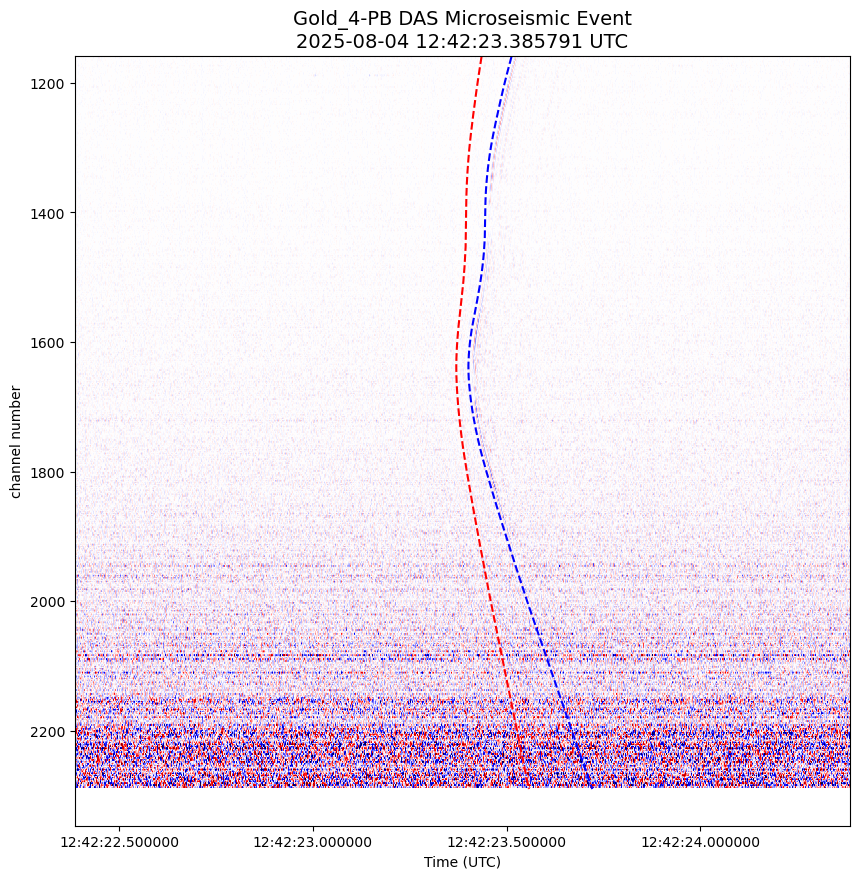

In [150]:
# === DATA WINDOW ===
D_window = D_all[tsb:tse, :].T
D_window=D_window[indices]
og_channels=list(channels.orig_channel)

# === COLOR SCALING BASED ON LOCAL MD RANGE ===
std_val = np.std(D_window)
vmax = 3 * std_val
vmin = -vmax

# === PLOT ==='     L2 msmx'
plt.figure(figsize=(10, 10))
img = plt.imshow(D_window, aspect='auto', cmap='seismic',
                 extent=(mdates.date2num(DT['DateTime'].iloc[tsb]),
                         mdates.date2num(DT['DateTime'].iloc[tse]),
                         indices[-1], indices[0]),
                         #depthsm[-1], depthsm[0]),
                 vmin=vmin, vmax=vmax)
plt.plot(ppicktimes, og_channels, 'r--')
plt.plot(spicktimes, og_channels, 'b--')
plt.title(f"{well_name} DAS Microseismic Event\n{target_time} UTC", fontsize=14)
plt.xlabel("Time (UTC)")
plt.ylabel("channel number")
plt.gca().xaxis_date()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S.%f'))

#what to export from running this 
#from original pick file: Date, Time, Location, Tzero, SourceX, SourceY, SourceZ
#from the processing here: spicktimes, ppicktimes, og_channels